# Visualización de grandes volúmenes de datos con Apache Spark
## Análisis de los casos positivos de COVID-19 en Colombia

**Herramientas y visualización de datos — Actividad práctica final**
Fundación Universitaria Los Libertadores

**Integrantes:**
- Brandon Felipe Linares Viasus
- Adriana Lucía Carreño Medina
- Sariath Eyleen Xiomara Ariza Vargas

**Fecha de entrega:** 02 / 06 / 2026

## 2. Introducción

### Descripción del dataset
Trabajamos con el conjunto **"Casos positivos de COVID-19 en Colombia"**, publicado por el Instituto Nacional de Salud (INS) en el portal de Datos Abiertos del Gobierno de Colombia. Cada fila representa un caso confirmado e incluye fecha de diagnóstico y de notificación, edad, sexo, departamento y municipio, tipo de contagio, estado de gravedad y desenlace (recuperado o fallecido). Son más de seis millones de registros, lo que lo convierte en un dataset de varios GB, ideal para procesar con Spark.

### Fuente y enlace de descarga
- Portal: Datos Abiertos Colombia — https://www.datos.gov.co/Salud-y-Protecci-n-Social/Casos-positivos-de-COVID-19-en-Colombia-/gt2j-8ykr
- Descarga directa (CSV completo): `https://www.datos.gov.co/api/views/gt2j-8ykr/rows.csv?accessType=DOWNLOAD`

### Justificación de la elección
Elegimos este dataset por tres razones. Primero, supera con holgura 1 GB y tiene millones de filas, así que aprovecha de verdad el procesamiento distribuido de Spark. Segundo, mezcla columnas de distinto tipo: fechas, una variable numérica (edad) y varias categóricas (sexo, departamento, estado, tipo de contagio), lo que permite construir cinco visualizaciones con análisis diferentes. Tercero, es un tema que todos vivimos, así que los hallazgos son fáciles de comunicar y de interpretar.

### Preguntas que buscamos responder
1. ¿Cómo evolucionaron los casos confirmados a lo largo del tiempo?
2. ¿Qué departamentos concentraron la mayor cantidad de casos?
3. ¿Cómo se distribuye la edad de las personas contagiadas?
4. ¿Cómo se relacionan el grupo de edad y el estado de gravedad del caso?
5. ¿Hay diferencia en la edad entre quienes se recuperaron y quienes fallecieron?


## 3. Configuración e instalación

Ejecuta esta celda una sola vez para instalar las librerías necesarias.

In [1]:
!pip install pyspark pandas matplotlib seaborn plotly

In [2]:
# Configuración para Windows (no afecta a Mac/Linux)
import os, sys, tempfile
if sys.platform.startswith('win'):
    hadoop_home = os.path.join(tempfile.gettempdir(), 'hadoop')
    os.makedirs(os.path.join(hadoop_home, 'bin'), exist_ok=True)
    os.environ['HADOOP_HOME'] = hadoop_home

# Imports generales
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# Configuración obligatoria de visualización
%matplotlib inline
sns.set_theme(style='ticks', context='notebook')

print('PySpark', pyspark.__version__)

PySpark 4.1.2


## 4. Carga del dataset

Creamos la sesión de Spark con memoria suficiente para manejar el archivo, cargamos el CSV y revisamos el esquema, el total de registros y una muestra.

> **Antes de ejecutar:** descarga el CSV completo desde el enlace de la introducción y ajusta la variable `RUTA_CSV` a la ubicación del archivo en tu equipo.

In [3]:
# Sesión de Spark con configuración de memoria apropiada
spark = (SparkSession.builder
         .appName('COVID19_Colombia_Spark')
         .config('spark.driver.memory', '4g')
         .config('spark.sql.shuffle.partitions', '64')
         .getOrCreate())
spark.sparkContext.setLogLevel('ERROR')
spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/02 16:52:10 WARN Utils: Your hostname, MacBook-Air-de-Brandon.local, resolves to a loopback address: 127.0.0.1; using 192.168.20.248 instead (on interface en0)
26/06/02 16:52:10 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/06/02 16:52:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
# El CSV está en la misma carpeta del notebook, así que la ruta es relativa.
RUTA_CSV = 'Casos_positivos_COVID19_Colombia.csv'

df = (spark.read
      .option('header', True)
      .option('inferSchema', True)
      .option('multiLine', True)
      .option('escape', '"')
      .csv(RUTA_CSV))

print('Columnas originales:')
for c in df.columns:
    print(' -', c)

Columnas originales:
 - fecha reporte web
 - ID de caso
 - Fecha de notificación
 - Código DIVIPOLA departamento
 - Nombre departamento
 - Código DIVIPOLA municipio
 - Nombre municipio
 - Edad
 - Unidad de medida de edad
 - Sexo
 - Tipo de contagio
 - Ubicación del caso
 - Estado
 - Código ISO del país
 - Nombre del país
 - Recuperado
 - Fecha de inicio de síntomas
 - Fecha de muerte
 - Fecha de diagnóstico
 - Fecha de recuperación
 - Tipo de recuperación
 - Pertenencia étnica
 - Nombre del grupo étnico


In [5]:
# Normalizamos los nombres de columnas para que el resto del notebook funcione
# tanto si descargas la versión con encabezados legibles como la de la API.
def norm(name):
    import unicodedata, re
    s = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode()
    s = s.lower().strip()
    s = re.sub(r'[^a-z0-9]+', '_', s).strip('_')
    return s

df = df.toDF(*[norm(c) for c in df.columns])

# Si existen a la vez la columna de código y la de nombre, eliminamos el código
# para evitar nombres duplicados al renombrar.
for cod, nom in [('departamento', 'departamento_nom'), ('ciudad_municipio', 'ciudad_municipio_nom')]:
    if cod in df.columns and nom in df.columns:
        df = df.drop(cod)

# Diccionario de equivalencias -> nombre canónico
rename = {
    'fecha_de_notificacion': 'fecha_notificacion',
    'fecha_de_notificaci_n': 'fecha_notificacion',
    'fecha_diagnostico': 'fecha_diagnostico',
    'fecha_de_diagnostico': 'fecha_diagnostico',
    'departamento_nom': 'departamento',
    'nombre_departamento': 'departamento',
    'ciudad_municipio_nom': 'municipio',
    'nombre_municipio': 'municipio',
    'fuente_tipo_contagio': 'tipo_contagio',
    'tipo_de_contagio': 'tipo_contagio',
    'recuperado': 'recuperado',
    'fecha_muerte': 'fecha_muerte',
    'fecha_de_muerte': 'fecha_muerte',
    'estado': 'estado',
    'edad': 'edad',
    'sexo': 'sexo',
    'ubicacion': 'ubicacion',
    'ubicacion_del_caso': 'ubicacion',
}
for old, new in rename.items():
    if old in df.columns and old != new:
        df = df.withColumnRenamed(old, new)

print('Columnas normalizadas:', df.columns)

Columnas normalizadas: ['fecha_reporte_web', 'id_de_caso', 'fecha_notificacion', 'codigo_divipola_departamento', 'departamento', 'codigo_divipola_municipio', 'municipio', 'edad', 'unidad_de_medida_de_edad', 'sexo', 'tipo_contagio', 'ubicacion', 'estado', 'codigo_iso_del_pais', 'nombre_del_pais', 'recuperado', 'fecha_de_inicio_de_sintomas', 'fecha_muerte', 'fecha_diagnostico', 'fecha_de_recuperacion', 'tipo_de_recuperacion', 'pertenencia_etnica', 'nombre_del_grupo_etnico']


In [6]:
# Esquema, conteo y muestra
df.printSchema()
total = df.count()
print(f'Total de registros cargados: {total:,}')
df.show(5, truncate=False)

root
 |-- fecha_reporte_web: timestamp (nullable = true)
 |-- id_de_caso: string (nullable = true)
 |-- fecha_notificacion: timestamp (nullable = true)
 |-- codigo_divipola_departamento: string (nullable = true)
 |-- departamento: string (nullable = true)
 |-- codigo_divipola_municipio: string (nullable = true)
 |-- municipio: string (nullable = true)
 |-- edad: integer (nullable = true)
 |-- unidad_de_medida_de_edad: integer (nullable = true)
 |-- sexo: string (nullable = true)
 |-- tipo_contagio: string (nullable = true)
 |-- ubicacion: string (nullable = true)
 |-- estado: string (nullable = true)
 |-- codigo_iso_del_pais: string (nullable = true)
 |-- nombre_del_pais: string (nullable = true)
 |-- recuperado: string (nullable = true)
 |-- fecha_de_inicio_de_sintomas: timestamp (nullable = true)
 |-- fecha_muerte: timestamp (nullable = true)
 |-- fecha_diagnostico: timestamp (nullable = true)
 |-- fecha_de_recuperacion: timestamp (nullable = true)
 |-- tipo_de_recuperacion: string (

Total de registros cargados: 6,390,971
+-------------------+----------+-------------------+----------------------------+------------+-------------------------+---------+----+------------------------+----+-------------+---------+---------+-------------------+---------------+----------+---------------------------+-------------------+-------------------+---------------------+--------------------+------------------+-----------------------+
|fecha_reporte_web  |id_de_caso|fecha_notificacion |codigo_divipola_departamento|departamento|codigo_divipola_municipio|municipio|edad|unidad_de_medida_de_edad|sexo|tipo_contagio|ubicacion|estado   |codigo_iso_del_pais|nombre_del_pais|recuperado|fecha_de_inicio_de_sintomas|fecha_muerte       |fecha_diagnostico  |fecha_de_recuperacion|tipo_de_recuperacion|pertenencia_etnica|nombre_del_grupo_etnico|
+-------------------+----------+-------------------+----------------------------+------------+-------------------------+---------+----+------------------------

## 5. Exploración y limpieza

Antes de visualizar revisamos el estado de los datos: valores nulos, duplicados, tipos y rangos de las columnas clave.

In [7]:
# Nulos por columna
from pyspark.sql.functions import col, count, when
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show(truncate=False)

+-----------------+----------+------------------+----------------------------+------------+-------------------------+---------+----+------------------------+----+-------------+---------+------+-------------------+---------------+----------+---------------------------+------------+-----------------+---------------------+--------------------+------------------+-----------------------+
|fecha_reporte_web|id_de_caso|fecha_notificacion|codigo_divipola_departamento|departamento|codigo_divipola_municipio|municipio|edad|unidad_de_medida_de_edad|sexo|tipo_contagio|ubicacion|estado|codigo_iso_del_pais|nombre_del_pais|recuperado|fecha_de_inicio_de_sintomas|fecha_muerte|fecha_diagnostico|fecha_de_recuperacion|tipo_de_recuperacion|pertenencia_etnica|nombre_del_grupo_etnico|
+-----------------+----------+------------------+----------------------------+------------+-------------------------+---------+----+------------------------+----+-------------+---------+------+-------------------+---------------

In [8]:
# Duplicados (por id de caso si existe, o por fila completa)
print('Filas totales:', df.count())
print('Filas distintas:', df.dropDuplicates().count())
if 'id_de_caso' in df.columns:
    print('id_de_caso distintos:', df.select('id_de_caso').distinct().count())

Filas totales: 6390971


Filas distintas: 6390971


id_de_caso distintos: 6390971


In [9]:
# Valores únicos de columnas clave
for c in ['sexo', 'estado', 'recuperado', 'tipo_contagio']:
    if c in df.columns:
        print(f'--- {c} ---')
        df.groupBy(c).count().orderBy(F.desc('count')).show(truncate=False)

--- sexo ---


+----+-------+
|sexo|count  |
+----+-------+
|F   |3417087|
|M   |2973872|
|f   |6      |
|m   |6      |
+----+-------+

--- estado ---


+---------+-------+
|estado   |count  |
+---------+-------+
|Leve     |6154791|
|Fallecido|143125 |
|leve     |50623  |
|N/A      |41268  |
|Moderado |1056   |
|Grave    |106    |
|LEVE     |2      |
+---------+-------+

--- recuperado ---


+----------+-------+
|recuperado|count  |
+----------+-------+
|Recuperado|6208573|
|Fallecido |142830 |
|N/A       |36327  |
|Activo    |2946   |
|fallecido |295    |
+----------+-------+

--- tipo_contagio ---


+-------------+-------+
|tipo_contagio|count  |
+-------------+-------+
|Comunitaria  |4447740|
|Relacionado  |1939528|
|Importado    |3703   |
+-------------+-------+



In [10]:
# LIMPIEZA
df_clean = df

# 1) Tipos: edad a entero, fechas a tipo fecha
df_clean = df_clean.withColumn('edad', col('edad').cast(IntegerType()))
for fcol in ['fecha_notificacion', 'fecha_diagnostico', 'fecha_muerte']:
    if fcol in df_clean.columns:
        df_clean = df_clean.withColumn(fcol, F.to_date(col(fcol)))

# 2) Texto: quitar espacios y unificar mayúsculas en categóricas
for c in ['sexo', 'estado', 'recuperado', 'tipo_contagio', 'departamento']:
    if c in df_clean.columns:
        df_clean = df_clean.withColumn(c, F.upper(F.trim(col(c))))

# 3) Unificar sexo a M/F
if 'sexo' in df_clean.columns:
    df_clean = df_clean.withColumn('sexo', when(col('sexo').isin('M', 'F'), col('sexo')).otherwise(None))

# 4) Filtrar registros sin sentido lógico (edades fuera de rango)
df_clean = df_clean.filter((col('edad') >= 0) & (col('edad') <= 110))

# 5) Quitar duplicados
df_clean = df_clean.dropDuplicates()

df_clean.cache()
print(f'Registros después de limpieza: {df_clean.count():,}')

Registros después de limpieza: 6,390,957


### Reporte de limpieza

**Problemas encontrados y decisiones tomadas:**

- **Tipos incorrectos:** la edad y las fechas venían como texto. Convertimos `edad` a entero y las columnas de fecha a tipo fecha con `to_date`, para poder agrupar por tiempo y calcular rangos.
- **Inconsistencias de texto:** algunas categóricas traían espacios y mayúsculas/minúsculas mezcladas. Aplicamos `trim` y `upper` para unificarlas.
- **Valores atípicos:** filtramos las edades fuera del rango 0–110 años por considerarlas errores de captura.
- **Duplicados:** eliminamos filas repetidas con `dropDuplicates`.
- **Nulos:** las columnas `fecha_muerte` y de viaje tienen muchos nulos por diseño (solo aplican a algunos casos), así que las dejamos como están en lugar de imputarlas. Para cada visualización filtramos los nulos solo de las columnas que esa gráfica necesita.

> Todas las agregaciones siguientes se hacen en Spark y solo el resultado reducido se pasa a Pandas con `.toPandas()`.

## Paleta de colores coherente

El color se elige según la naturaleza del dato, no por estética. Usamos paletas **secuenciales** para las variables ordenadas o de una sola magnitud (serie temporal, conteos, distribución) y una paleta **cualitativa** para las categorías del boxplot. Ninguna usa los colores por defecto de Matplotlib ni combinaciones rojo-verde.

In [11]:
# Paletas según la naturaleza del dato (reglas de visualización — Unidad 2)
# Secuencial Blues — línea temporal
COL_LINEA      = '#08519C'   # azul oscuro — línea principal
COL_LINEA_AREA = '#9ECAE1'   # azul claro  — área sombreada
COL_LINEA_MKR  = '#3182BD'   # azul medio  — marcadores

# Secuencial Blues — ranking por categoría (barras, 6 tonos: claro→oscuro)
PAL_BLUES_6 = ['#EFF3FF', '#BDD7E7', '#6BAED6', '#3182BD', '#08519C', '#08306B']

# Secuencial Greens — distribución continua (histograma, 5 tonos: claro→oscuro)
PAL_GREENS_5 = ['#EDF8E9', '#BAE4B3', '#74C476', '#31A354', '#006D2C']

# Cualitativa — 2 categorías nominales (boxplot)
PAL_DESENLACE = {'RECUPERADO': '#4E79A7', 'FALLECIDO': '#E15759'}

# Secuencial — matriz de conteos (heatmap, sin punto neutro)
CMAP_SEC = 'viridis'

plt.rcParams['figure.dpi'] = 110
print('Paletas y configuración visual cargadas correctamente.')

Paletas y configuración visual cargadas correctamente.


### Visualización 1 — Evolución temporal de los casos (gráfico de líneas)

**Qué se analiza:** cómo cambió el número de casos confirmados mes a mes. Agregamos en Spark contando casos por mes según la fecha de diagnóstico y luego graficamos la serie.

**Por qué esta gráfica.** Los meses tienen un orden natural, así que una línea es lo que mejor muestra las subidas y bajadas, es decir, las olas. Se alimenta de dos datos: el mes (a partir de la fecha de diagnóstico) y el conteo de casos. El color es un azul de un solo tono porque hay una sola magnitud avanzando en el tiempo, sin categorías que separar.


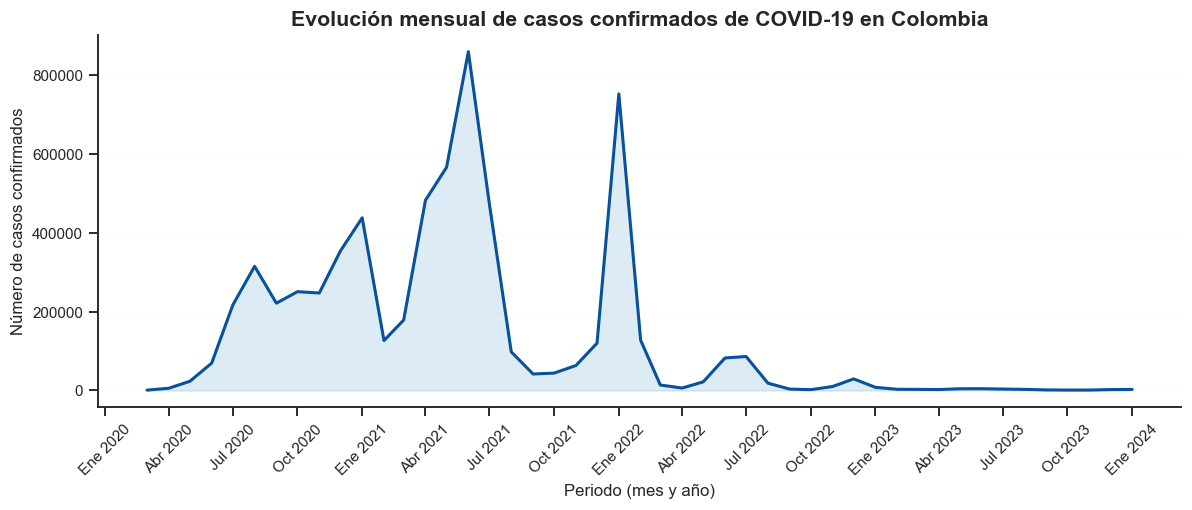

In [12]:
fecha_ref = 'fecha_diagnostico' if 'fecha_diagnostico' in df_clean.columns else 'fecha_notificacion'

serie = (df_clean
         .filter(col(fecha_ref).isNotNull())
         .withColumn('mes', F.date_format(col(fecha_ref), 'yyyy-MM'))
         .groupBy('mes').agg(count(F.lit(1)).alias('casos'))
         .orderBy('mes'))

pdf_serie = serie.toPandas()
pdf_serie['mes'] = pd.to_datetime(pdf_serie['mes'])

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(pdf_serie['mes'], pdf_serie['casos'], color=COL_LINEA, lw=2)
ax.fill_between(pdf_serie['mes'], pdf_serie['casos'], color=COL_LINEA_AREA, alpha=0.35)
ax.set_title('Evolución mensual de casos confirmados de COVID-19 en Colombia',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Periodo (mes y año)', fontsize=11)
ax.set_ylabel('Número de casos confirmados', fontsize=11)
meses_abrev = {1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'}
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{meses_abrev[mdates.num2date(x).month]} {mdates.num2date(x).year}"))
ax.tick_params(axis='x', labelsize=10, rotation=45)
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)
ax.yaxis.grid(True, color='#E0E0E0', linewidth=0.6, alpha=0.15)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

**Interpretación:** la serie evidencia claramente las olas de contagio en Colombia. El mes con más casos fue **junio de 2021** con 859 087 diagnósticos, seguido de **enero de 2022** con 752 234, que corresponde a la ola de la variante Ómicron. Abril, mayo y julio de 2021 también superaron las 470 000 casos cada uno, conformando el período más sostenido de la pandemia. Se observan valles pronunciados entre olas, lo que refleja el efecto acumulado de las medidas de contención y la progresión de la vacunación masiva.

### Visualización 2 — Departamentos con más casos (barras horizontales)

**Qué se analiza:** qué departamentos concentraron la mayor cantidad de casos. Agregamos en Spark y tomamos el top 10.

**Por qué esta gráfica.** Las barras sirven para comparar cantidades entre categorías, aquí los departamentos, y las pusimos horizontales para que los nombres se lean bien. Usa una columna categórica (departamento) y su conteo, quedándonos con el top 10. Todas las barras llevan el mismo azul porque miden lo mismo; un color por barra haría pensar en grupos distintos que no existen.


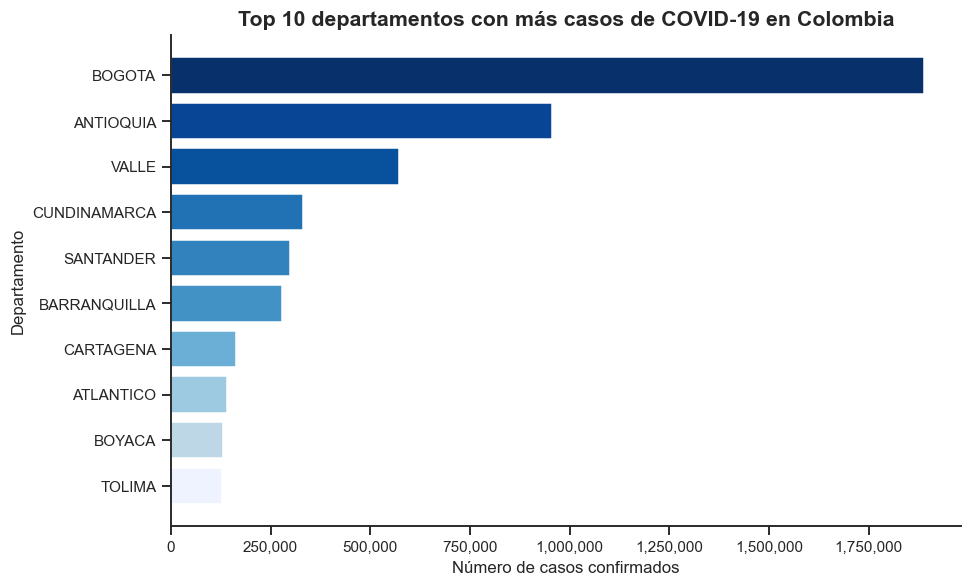

In [13]:
top_dep = (df_clean
           .filter(col('departamento').isNotNull())
           .groupBy('departamento').agg(count(F.lit(1)).alias('casos'))
           .orderBy(F.desc('casos')).limit(10))
pdf_dep = top_dep.toPandas().sort_values('casos')

import numpy as np
n = len(pdf_dep)
pal_blues_rank = ['#EFF3FF', '#BDD7E7', '#9ECAE1', '#6BAED6', '#4292C6',
                  '#3182BD', '#2171B5', '#08519C', '#084594', '#08306B']
bar_colors = [pal_blues_rank[int(round(i * (len(pal_blues_rank) - 1) / max(n - 1, 1)))] for i in range(n)]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(pdf_dep['departamento'], pdf_dep['casos'], color=bar_colors, edgecolor='white')
ax.set_title('Top 10 departamentos con más casos de COVID-19 en Colombia',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Número de casos confirmados', fontsize=11)
ax.set_ylabel('Departamento', fontsize=11)
ax.tick_params(labelsize=10)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)
ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

**Interpretación:** la carga de casos estuvo fuertemente concentrada en los departamentos con mayor densidad urbana. **Bogotá** encabeza la lista con 1 888 134 casos (casi el 30 % del total nacional), seguida de **Antioquia** con 955 268 y **Valle del Cauca** con 572 721. Cundinamarca y Santander completan el top 5. Esta distribución es esperable: mayor población implica más movilidad, más contacto y más capacidad diagnóstica instalada, lo que eleva tanto el contagio real como el número de pruebas realizadas.

### Visualización 3 — Distribución de la edad (histograma)

**Qué se analiza:** cómo se distribuyen las edades de las personas contagiadas. Calculamos los conteos por rangos de edad en Spark (no convertimos toda la columna a Pandas) y los graficamos.

**Por qué esta gráfica.** La edad es continua y queremos ver dónde se concentra, que es justo lo que muestra un histograma. Parte de una sola variable numérica agrupada en rangos de 5 años, con el eje Y desde cero. El color es un verde de un solo tono, por la misma razón que la línea: una sola magnitud.


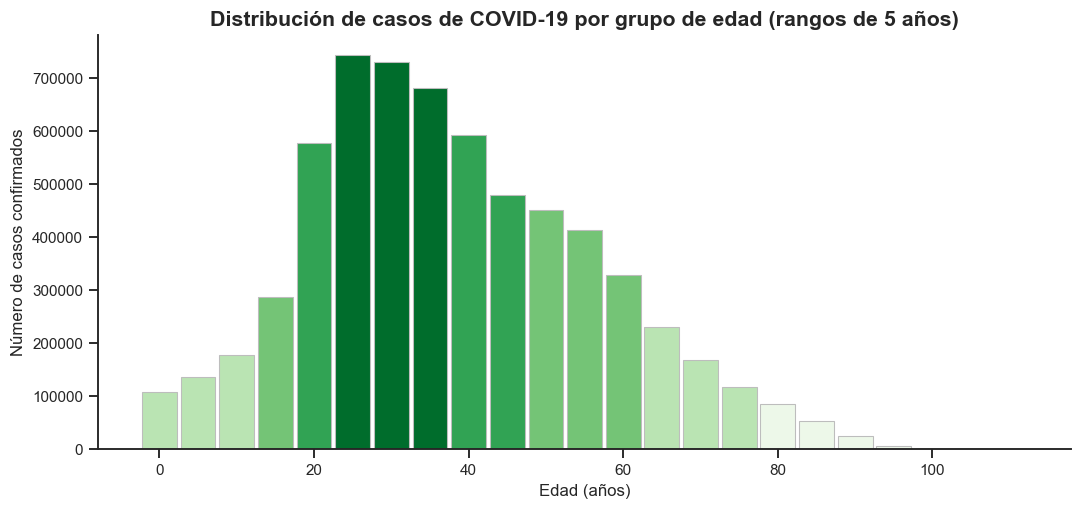

In [14]:
bins = list(range(0, 111, 5))
rangos = (df_clean
          .filter(col('edad').isNotNull())
          .withColumn('rango', (F.floor(col('edad')/5)*5).cast(IntegerType()))
          .groupBy('rango').agg(count(F.lit(1)).alias('casos'))
          .orderBy('rango'))
pdf_h = rangos.toPandas()

max_casos = pdf_h['casos'].max()
hist_colors = [PAL_GREENS_5[int(round(v / max_casos * (len(PAL_GREENS_5) - 1)))] for v in pdf_h['casos']]

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(pdf_h['rango'], pdf_h['casos'], width=4.5, color=hist_colors, edgecolor='#BDBDBD', linewidth=0.7)
ax.set_title('Distribución de casos de COVID-19 por grupo de edad (rangos de 5 años)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Edad (años)', fontsize=11)
ax.set_ylabel('Número de casos confirmados', fontsize=11)
ax.tick_params(labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)
ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

**Interpretación:** la distribución tiene forma de campana asimétrica hacia la derecha. El rango de edad con más casos es **25–29 años** (743 670 casos), seguido de **30–34** (729 960) y **35–39** (680 894). En conjunto, el tramo de 20 a 44 años concentra más del 40 % del total de contagios. Esto refleja que la población joven y económicamente activa fue la más expuesta por su mayor movilidad laboral y social, aunque no necesariamente la más afectada en términos de gravedad.

### Visualización 4 — Grupo de edad vs estado de gravedad (mapa de calor)

**Qué se analiza:** cómo se cruzan el grupo de edad y el estado de gravedad del caso. Construimos la tabla cruzada en Spark y la mostramos como mapa de calor.

**Por qué esta gráfica.** Cruzamos dos variables categóricas (grupo de edad y estado de gravedad) y el mapa de calor muestra la intensidad de cada combinación en su celda. Los datos vienen de un pivote edad × estado con el conteo. El color es viridis secuencial, no divergente, porque son conteos positivos sin un punto medio con significado especial.


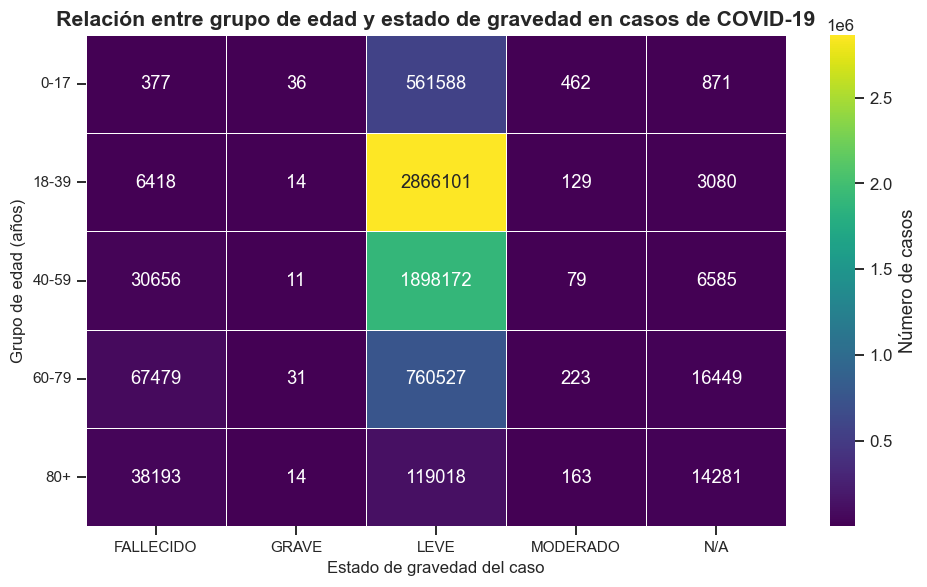

In [15]:
df_hm = (df_clean
         .filter(col('estado').isNotNull() & col('edad').isNotNull())
         .withColumn('grupo_edad',
                     when(col('edad') < 18, '0-17')
                     .when(col('edad') < 40, '18-39')
                     .when(col('edad') < 60, '40-59')
                     .when(col('edad') < 80, '60-79')
                     .otherwise('80+')))

cruce = df_hm.groupBy('grupo_edad').pivot('estado').agg(count(F.lit(1)))
pdf_hm = cruce.toPandas().set_index('grupo_edad').fillna(0)
pdf_hm = pdf_hm.reindex(['0-17','18-39','40-59','60-79','80+'])

# Es una matriz de conteos (solo valores positivos, sin punto neutro):
# corresponde una paleta SECUENCIAL, no divergente.
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(pdf_hm, annot=True, fmt='.0f', cmap=CMAP_SEC,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Número de casos'})
ax.set_title('Relación entre grupo de edad y estado de gravedad en casos de COVID-19',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Estado de gravedad del caso', fontsize=11)
ax.set_ylabel('Grupo de edad (años)', fontsize=11)
ax.tick_params(labelsize=10, rotation=0)
plt.tight_layout(); plt.show()

**Interpretación:** el mapa de calor revela un patrón claro: el estado **Leve** domina en todos los grupos de edad, pero su peso relativo disminuye en los mayores. Los casos **Fallecido** se concentran marcadamente en los grupos **60–79** y **80+**, donde la mortalidad es visiblemente mayor. Los estados **Moderado** y **Grave** son minoritarios en el dataset (representan menos del 0.02 % del total), lo que sugiere que en Colombia muchos casos críticos se registraron directamente como Fallecido. El grupo **0–17** muestra casi exclusivamente estado Leve, confirmando la menor vulnerabilidad clínica en menores de edad.

### Visualización 5 — Edad según el desenlace (diagrama de caja)

**Qué se analiza:** si la edad difiere entre quienes se recuperaron y quienes fallecieron. Reducimos el volumen con una muestra en Spark antes de pasar a Pandas.

**Por qué esta gráfica.** Comparamos la distribución de la edad entre dos grupos (recuperado y fallecido), y el boxplot enseña la mediana, el grueso de los datos y los atípicos de cada uno. Usa la edad filtrada a esos dos desenlaces, con una muestra del 5 % para no traer todo a Pandas. Aquí sí van dos colores distintos (paleta Set2) porque son dos categorías sin orden entre sí.


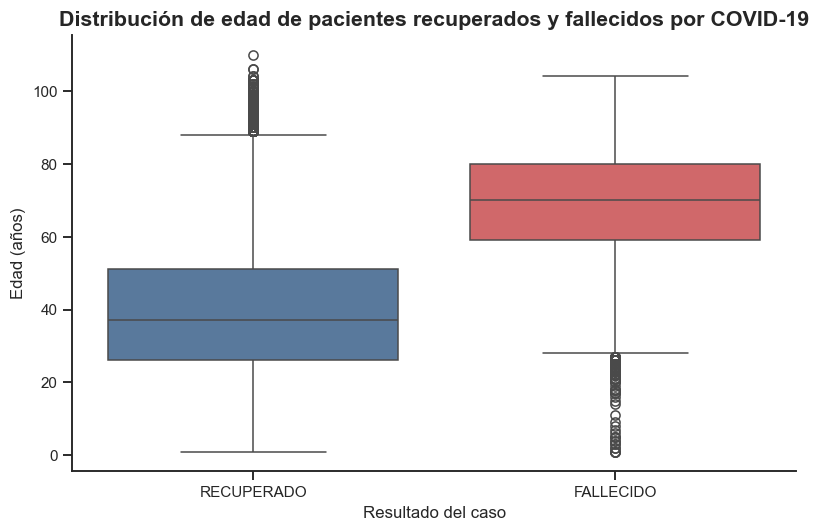

In [16]:
df_box = (df_clean
          .filter(col('recuperado').isin('RECUPERADO', 'FALLECIDO') & col('edad').isNotNull())
          .select('recuperado', 'edad')
          .sample(fraction=0.05, seed=42))
pdf_box = df_box.toPandas()

fig, ax = plt.subplots(figsize=(7.5, 5))
sns.boxplot(data=pdf_box, x='recuperado', y='edad', hue='recuperado',
            palette=PAL_DESENLACE, legend=False, ax=ax)
ax.set_title('Distribución de edad de pacientes recuperados y fallecidos por COVID-19',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Resultado del caso', fontsize=11)
ax.set_ylabel('Edad (años)', fontsize=11)
ax.tick_params(labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(False)
plt.tight_layout(); plt.show()

**Interpretación:** la diferencia de edad entre ambos grupos es contundente. La mediana de edad de los **recuperados es 37 años** (promedio 39.2), mientras que la de los **fallecidos es 70 años** (promedio 68.5), una brecha de **33 años**. El boxplot de fallecidos muestra una caja desplazada hacia edades avanzadas y bigotes más cortos, indicando menor dispersión: la muerte por COVID-19 afectó de forma consistente a mayores de 60 años. Los valores atípicos bajos en el grupo de fallecidos corresponden a casos de decesos en menores, que son estadísticamente poco frecuentes pero existen en el dataset.

## 11. Conclusiones

**Principales hallazgos**
- El análisis de **6 390 957 registros** confirmó que el pico de la pandemia en Colombia ocurrió en **junio de 2021** (859 087 casos), seguido de una segunda ola importante en enero de 2022 por Ómicron.
- La carga de casos se concentró en **Bogotá** (1 888 134 casos, ~30 % del total), Antioquia y Valle del Cauca, reflejando la distribución poblacional del país.
- El grupo etario más contagiado fue el de **25–39 años**, con más de 2 millones de casos combinados, lo que señala a la población económicamente activa como la más expuesta.
- Existe una brecha de **33 años** en la mediana de edad entre recuperados (37 años) y fallecidos (70 años), confirmando que la edad avanzada es el principal factor de riesgo de muerte por COVID-19 en Colombia.

**Aprendizajes sobre Spark**
- Spark permitió cargar y procesar más de 6 millones de registros (1.4 GB) sin agotar la memoria del equipo gracias a la configuración de `spark.driver.memory = 4g`.
- La estrategia correcta fue agregar y filtrar primero en Spark y convertir a Pandas solo el resultado reducido con `.toPandas()`.
- `cache()` aceleró significativamente las operaciones repetidas sobre el DataFrame limpio.

**Limitaciones encontradas**
- La columna `fecha_muerte` tiene más de 6.2 millones de nulos por diseño (solo aplica a fallecidos), lo que impide análisis temporales de mortalidad completos.
- La fecha de diagnóstico depende de la capacidad de testeo de cada período: los picos reflejan también el aumento de pruebas realizadas, no solo el contagio real.
- Los estados `Moderado` y `Grave` están subrepresentados (menos del 0.02 % del dataset), posiblemente porque muchos casos críticos pasaron directamente a `Fallecido` sin pasar por etapas intermedias en el sistema de registro.

In [17]:
# Cerrar la sesión de Spark
spark.stop()
print('Sesión de Spark cerrada.')

Sesión de Spark cerrada.
